# Imports

In [1]:
import time as tm
import numpy as np
import pandas as pd
import joblib as jb
import seaborn as sns
import gensim as gns
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import confusion_matrix

# Limpeza dos Dados

In [172]:
df = pd.read_csv('SQLiV3.csv', encoding='utf-8')

In [173]:
display(df)

,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN
30915,DELETE FROM tomorrow,0,NaN,NaN
30916,SELECT wide ( s ) FROM west,0,NaN,NaN
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN


In [174]:
df = df.drop(columns=['Unnamed: 2','Unnamed: 3'])
display(df)

,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
...,...,...
30914,DELETE FROM door WHERE grow = 'small',0
30915,DELETE FROM tomorrow,0
30916,SELECT wide ( s ) FROM west,0
30917,SELECT * FROM ( SELECT slide FROM breath ),0


### Verificando a quantidade de valores ausentes e removendo eles

In [175]:
df.describe()

,Sentence,Label
count,30904,30664
unique,30872,42
top,#NAME?,0
freq,8,19268


In [176]:
df['Label'].isna().sum()

255

In [177]:
df = df.dropna()
df['Label'].isna().sum()

0

In [178]:
df.describe()

,Sentence,Label
count,30649,30649
unique,30627,28
top,#NAME?,0
freq,8,19268


### Removendo dados no target que não são 0 e nem 1 (Dados sujos)

In [179]:
display(df)

,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
5,select name from syscolumns where id = ...,1
...,...,...
30914,DELETE FROM door WHERE grow = 'small',0
30915,DELETE FROM tomorrow,0
30916,SELECT wide ( s ) FROM west,0
30917,SELECT * FROM ( SELECT slide FROM breath ),0


In [180]:
df[~df['Label'].isin(['0', '1'])]

,Sentence,Label
193,1,SELECT *
195,x' and 1 = ( select count ( * ) from...,--
204,\',desc users
251,23 or 1 = 1,--
264,&apos,OR
362,x' AND userid IS NULL,--
377,x' and members.email is NULL,--
409,) ),waitfor delay '0:0:__TIME__'--
420,1' and 1 = ( select count ( * ) from...,--
447,,drop table temp --


In [181]:
df = df[df['Label'].isin(['0', '1'])]
display(df)

,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
5,select name from syscolumns where id = ...,1
...,...,...
30914,DELETE FROM door WHERE grow = 'small',0
30915,DELETE FROM tomorrow,0
30916,SELECT wide ( s ) FROM west,0
30917,SELECT * FROM ( SELECT slide FROM breath ),0


### Convertendo o tipo da coluna Target para int

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30609 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sentence  30609 non-null  object
 1   Label     30609 non-null  object
dtypes: object(2)
memory usage: 717.4+ KB


In [183]:
df['Label'] = df['Label'].astype('int')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30609 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sentence  30609 non-null  object
 1   Label     30609 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 717.4+ KB


### Remover as linhas em que a coluna 'Sentence' está vazia

In [184]:
df = df[~df['Sentence'].str.strip().eq('')]

### Usar o Lower nas Linhas da coluna 'Sentence'

In [185]:
df['Sentence'] = df['Sentence'].str.lower()
display(df)

,Sentence,Label
0,""" or pg_sleep ( __time__ ) --",1
2,and 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
5,select name from syscolumns where id = ...,1
...,...,...
30914,delete from door where grow = 'small',0
30915,delete from tomorrow,0
30916,select wide ( s ) from west,0
30917,select * from ( select slide from breath ),0


### Exportando dataset higienizado

In [186]:
df.to_csv('SQLiV3_Clean.csv', index=False)

### Countplot para verificar as quantidades em ambas as classes

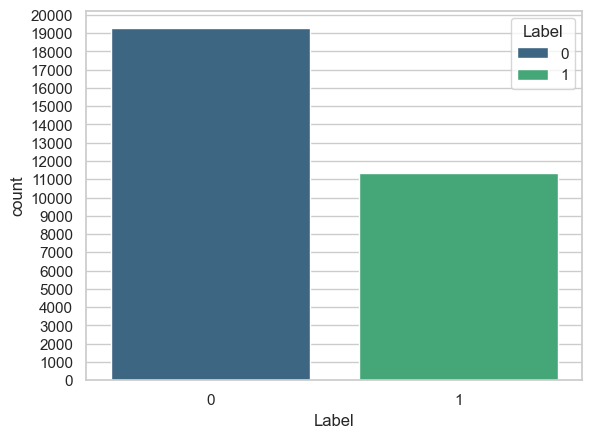

In [187]:
sns.countplot(x = 'Label', data=df, hue = 'Label', palette = 'viridis')
sns.set_theme(style="whitegrid")
plt.yticks(np.arange(0, 21000, 1000))
plt.show()

# Etapas do Treinamento

In [188]:
X = df['Sentence'].values
y = df['Label'].values

### Usando o TF-IDF para vetorizar os códigos de SQL

In [19]:
start_time = tm.time()
vectorizer = TfidfVectorizer(use_idf=True)
X_vectorizer = vectorizer.fit_transform(X)
end_time = tm.time()
print(f"Tempo de Vetorização: {end_time - start_time}")
#vectorizer = CountVectorizer(min_df = 100, max_df = 0.8, stop_words = 'english')
#X_vectorizer = vectorizer.fit_transform(X)

Tempo de Vetorização: 0.3693978786468506


### SMOTE (Cria amostra sintéticas da menor classe para balancear)

In [57]:
quantidades = np.bincount(y)

print("Quantidade de 0s:", quantidades[0])
print("Quantidade de 1s:", quantidades[1])

smote = SMOTE(random_state=7)
X_vectorizer, y = smote.fit_resample(X_vectorizer, y)

quantidades = np.bincount(y)

print("\nQuantidade de 0s:", quantidades[0])
print("Quantidade de 1s:", quantidades[1])

Quantidade de 0s: 19268
Quantidade de 1s: 11340

Quantidade de 0s: 19268
Quantidade de 1s: 19268


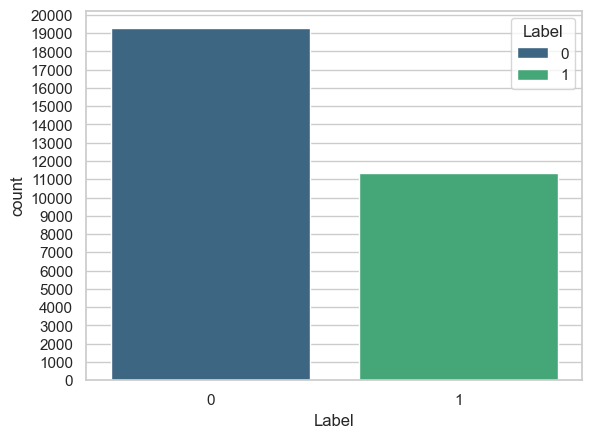

In [20]:
plot = pd.DataFrame(y, columns=["Label"])
sns.countplot(x = 'Label', data=plot, hue = 'Label', palette = 'viridis')
sns.set_theme(style="whitegrid")
plt.yticks(np.arange(0, 21000, 1000))
plt.show()

### Dividindo o dataset entre treinamento e teste

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_vectorizer, y, test_size=0.2, random_state=7, shuffle=True)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24486, 24660)
(6122, 24660)
(24486,)
(6122,)


### SMOTE (Cria amostra sintéticas da menor classe para balancear)

In [231]:
quantidades = np.bincount(y_train)

print("Quantidade de 0s:", quantidades[0])
print("Quantidade de 1s:", quantidades[1])

smote = SMOTE(random_state=7)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

quantidades = np.bincount(y_train_smote)

print("\nQuantidade de 0s:", quantidades[0])
print("Quantidade de 1s:", quantidades[1])

Quantidade de 0s: 15354
Quantidade de 1s: 9132

Quantidade de 0s: 15354
Quantidade de 1s: 15354


In [233]:
print(X_train_smote.shape)
print(X_test.shape)
print(y_train_smote.shape)
print(y_test.shape)

(30708, 24660)
(6122, 24660)
(30708,)
(6122,)


In [27]:
class_names = ["Normal", "Fraude"]

### 1º Treinamento do Random Forest (Usando Nada)

In [22]:
seed = 7

In [75]:
model_rf = RandomForestClassifier(n_estimators = 50, random_state = seed, class_weight={0:0.6, 1:1.10}).fit(X_train, y_train)
print(model_rf.score(X_test, y_test), '\n')
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

0.779157138190134 

              precision    recall  f1-score   support

           0     0.9996    0.6548    0.7913      3914
           1     0.6203    0.9995    0.7655      2208

    accuracy                         0.7792      6122
   macro avg     0.8100    0.8272    0.7784      6122
weighted avg     0.8628    0.7792    0.7820      6122



[[2564 1350]
 [   3 2205]]


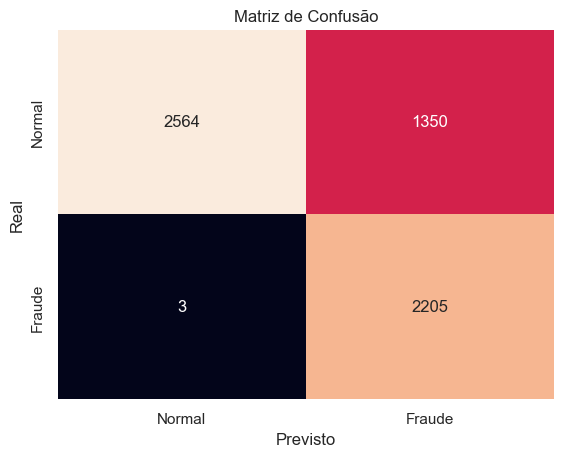

In [1690]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.savefig('cm_t1.png', dpi=300, bbox_inches='tight')
plt.show()

In [1691]:
depths = [tree.tree_.max_depth for tree in model_rf.estimators_]
soma = 0
menor = float('inf')
maior = float('-inf')
cnt = 0

for i, depth in enumerate(depths):
    #print(f"Árvore {i}: Profundidade = {depth}")
    soma += depth
    cnt += 1
    if(depth < menor):
        menor = depth
    if(depth > maior):
        maior = depth

print(f"MENOR PROFUNDIDADE: {menor}")
print(f"MAIOR PROFUNDIDADE: {maior}")
print(f"\nMÉDIA DAS PROFUNDIDADES: {round(soma/cnt)}")

MENOR PROFUNDIDADE: 3457
MAIOR PROFUNDIDADE: 3895

MÉDIA DAS PROFUNDIDADES: 3595


In [1693]:
scores = cross_val_score(model_rf, X_train, y_train, cv=5, scoring="accuracy")
print(f"Validação Cruzada Scores: {scores}")
print(f"Média da Validação Cruzada: {scores.mean()}")

Validação Cruzada Scores: [0.78481013 0.78088626 0.78701246 0.78435777 0.79170921]
Média da Validação Cruzada: 0.7857551639727759


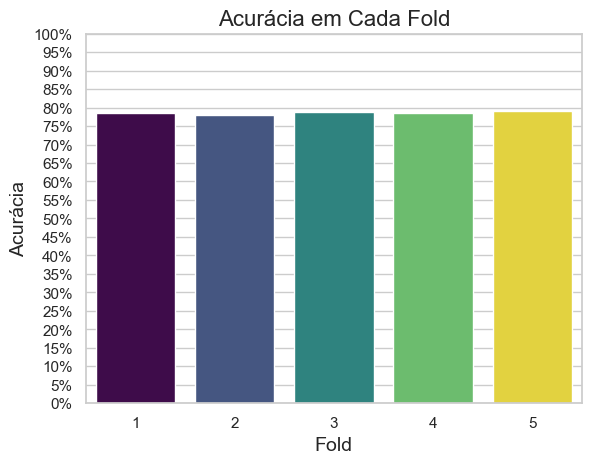

In [39]:
df = pd.DataFrame({'Fold': range(1, 6), 'Accuracy': scores})

sns.set_theme(style="whitegrid")
bar_plot = sns.barplot(x='Fold', y='Accuracy', data=df, hue='Fold', palette='viridis', errorbar=None, legend=False)
plt.gca().set_yticks([i / 100 for i in range(100, -1, -5)])
plt.gca().set_yticklabels([f'{i}%' for i in range(100, -1, -5)])
plt.title('Acurácia em Cada Fold', fontsize=16)
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Acurácia', fontsize=14)
plt.savefig('vc_t1.png', dpi=300, bbox_inches='tight')
plt.show()

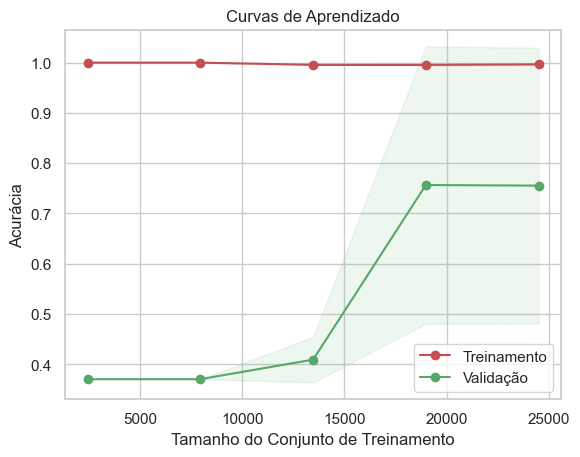

In [604]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X_vectorizer, y, cv=5, scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Acurácia')
plt.title('Curvas de Aprendizado')
plt.savefig('ca_t1.png', dpi=300, bbox_inches='tight')
plt.legend(loc='best')
plt.show()

### 2º Treinamento do Random Forest (Usando Smote)

In [243]:
model_rf = RandomForestClassifier(n_estimators = 50, random_state = seed, class_weight={0:1, 1:5}).fit(X_train, y_train)
print(model_rf.score(X_test, y_test), '\n')
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

0.7786671022541654 

              precision    recall  f1-score   support

           0     0.9996    0.6541    0.7907      3914
           1     0.6198    0.9995    0.7651      2208

    accuracy                         0.7787      6122
   macro avg     0.8097    0.8268    0.7779      6122
weighted avg     0.8626    0.7787    0.7815      6122



In [236]:
model_rf = RandomForestClassifier(n_estimators = 50, random_state = seed).fit(X_train_smote, y_train_smote)
print(model_rf.score(X_test, y_test), '\n')
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

0.7793204835021235 

              precision    recall  f1-score   support

           0     0.9996    0.6551    0.7915      3914
           1     0.6205    0.9995    0.7657      2208

    accuracy                         0.7793      6122
   macro avg     0.8100    0.8273    0.7786      6122
weighted avg     0.8629    0.7793    0.7822      6122



[[2564 1350]
 [   1 2207]]


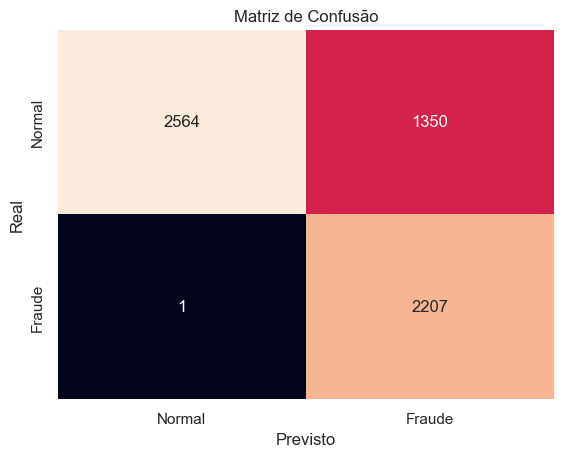

In [220]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.savefig('cm_t2.png', dpi=300, bbox_inches='tight')
plt.show()

In [1674]:
depths = [tree.tree_.max_depth for tree in model_rf.estimators_]
soma = 0
menor = float('inf')
maior = float('-inf')
cnt = 0

for i, depth in enumerate(depths):
    #print(f"Árvore {i}: Profundidade = {depth}")
    soma += depth
    cnt += 1
    if(depth < menor):
        menor = depth
    if(depth > maior):
        maior = depth

print(f"MENOR PROFUNDIDADE: {menor}")
print(f"MAIOR PROFUNDIDADE: {maior}")
print(f"\nMÉDIA DAS PROFUNDIDADES: {round(soma/cnt)}")

MENOR PROFUNDIDADE: 3440
MAIOR PROFUNDIDADE: 3877

MÉDIA DAS PROFUNDIDADES: 3598


In [221]:
scores = cross_val_score(model_rf, X_train, y_train, cv=5, scoring="balanced_accuracy")
print(f"Validação Cruzada Scores: {scores}")
print(f"Média da Validação Cruzada: {scores.mean()}")

Validação Cruzada Scores: [0.82774341 0.82578965 0.82985998 0.82790611 0.83257329]
Média da Validação Cruzada: 0.8287744869786391


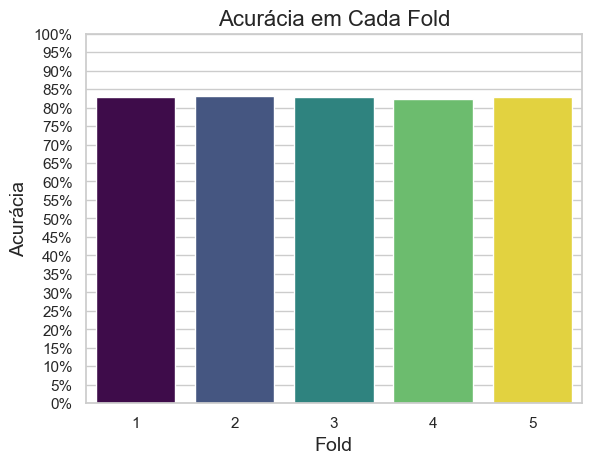

In [67]:
df = pd.DataFrame({'Fold': range(1, 6), 'Accuracy': scores})

sns.set_theme(style="whitegrid")
bar_plot = sns.barplot(x='Fold', y='Accuracy', data=df, hue='Fold', palette='viridis', errorbar=None, legend=False)
plt.gca().set_yticks([i / 100 for i in range(100, -1, -5)])
plt.gca().set_yticklabels([f'{i}%' for i in range(100, -1, -5)])
plt.title('Acurácia em Cada Fold', fontsize=16)
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Acurácia', fontsize=14)
plt.savefig('vc_t2.png', dpi=300, bbox_inches='tight')
plt.show()

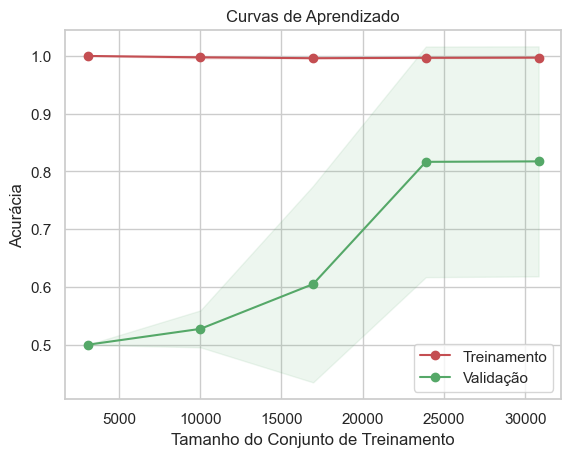

In [612]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X_vectorizer, y, cv=5, scoring='balanced_accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Acurácia')
plt.title('Curvas de Aprendizado')
plt.savefig('ca_t2.png', dpi=300, bbox_inches='tight')
plt.legend(loc='best')
plt.show()

### 3º Treinamento do Random Forest (Usando Smote e Features Selection do treinamento 2)

In [24]:
importances = model_rf.feature_importances_
print(f"{len(importances)}\n")
#print(sorted(importances,reverse=True))

threshold = 2e-5

important_features = [feature for feature, importance in zip(vectorizer.get_feature_names_out() , importances) if importance >= threshold]
#print(type(X_train))
print(f"Variáveis importantes: {len(important_features)}\n")
#print(f"Variáveis importantes: {important_features}")

feature_names = vectorizer.get_feature_names_out()
important_indices = [list(feature_names).index(feature) for feature in important_features]
X_vectorizer_reduced = X_vectorizer[:, important_indices]
X_train_reduced = X_train[:, important_indices]
#X_train_reduced = X_train[important_features]
X_test_reduced = X_test[:, important_indices]

print(X_train_reduced.shape[1])

24660

Variáveis importantes: 1876

1876


In [29]:
quantidades = np.bincount(y_train)

print("Quantidade de 0s:", quantidades[0])
print("Quantidade de 1s:", quantidades[1])

smote = SMOTE(random_state=7)
X_train_reduced_smote, y_train_smote = smote.fit_resample(X_train_reduced, y_train)

quantidades = np.bincount(y_train_smote)

print("\nQuantidade de 0s:", quantidades[0])
print("Quantidade de 1s:", quantidades[1])

Quantidade de 0s: 15354
Quantidade de 1s: 9132

Quantidade de 0s: 15354
Quantidade de 1s: 15354


In [233]:
print(X_train_smote.shape)
print(X_test.shape)
print(y_train_smote.shape)
print(y_test.shape)

(30708, 24660)
(6122, 24660)
(30708,)
(6122,)


In [30]:
model_rf = RandomForestClassifier(random_state = seed).fit(X_train_reduced_smote, y_train_smote)
print(model_rf.score(X_test_reduced, y_test), '\n')
y_pred = model_rf.predict(X_test_reduced)
print(classification_report(y_test, y_pred, digits=4))

0.9954263312642927 

              precision    recall  f1-score   support

           0     0.9939    0.9990    0.9964      3914
           1     0.9982    0.9891    0.9936      2208

    accuracy                         0.9954      6122
   macro avg     0.9960    0.9941    0.9950      6122
weighted avg     0.9954    0.9954    0.9954      6122



[[3910    4]
 [  24 2184]]


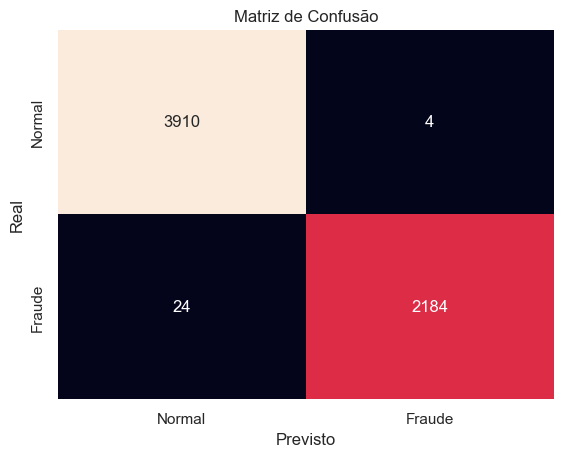

In [31]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.savefig('cm_t3.png', dpi=300, bbox_inches='tight')
plt.show()

In [64]:
depths = [tree.tree_.max_depth for tree in model_rf.estimators_]
soma = 0
menor = float('inf')
maior = float('-inf')
cnt = 0

for i, depth in enumerate(depths):
    #print(f"Árvore {i}: Profundidade = {depth}")
    soma += depth
    cnt += 1
    if(depth < menor):
        menor = depth
    if(depth > maior):
        maior = depth

print(f"MENOR PROFUNDIDADE: {menor}")
print(f"MAIOR PROFUNDIDADE: {maior}")
print(f"\nMÉDIA DAS PROFUNDIDADES: {round(soma/cnt)}")

MENOR PROFUNDIDADE: 156
MAIOR PROFUNDIDADE: 287

MÉDIA DAS PROFUNDIDADES: 205


In [29]:
scores = cross_val_score(model_rf, X_train_reduced, y_train, cv=5, scoring="accuracy")
print(f"Validação Cruzada Scores: {scores}")
print(f"Média da Validação Cruzada: {scores.mean()}")

Validação Cruzada Scores: [0.99387505 0.99489483 0.99509904 0.99591587 0.99509904]
Média da Validação Cruzada: 0.9949767663854996


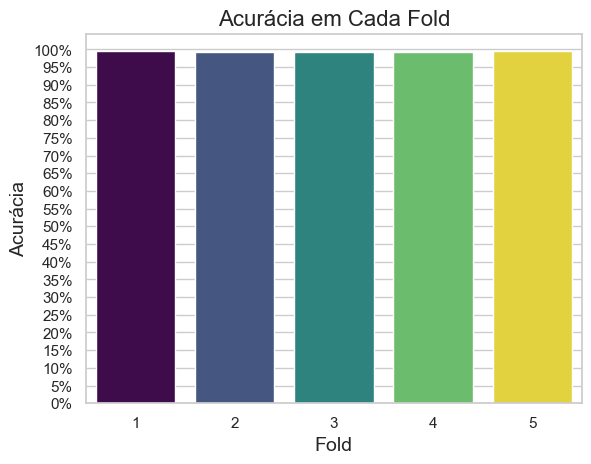

In [1709]:
df = pd.DataFrame({'Fold': range(1, 6), 'Accuracy': scores})

sns.set_theme(style="whitegrid")
bar_plot = sns.barplot(x='Fold', y='Accuracy', data=df, hue='Fold', palette='viridis', errorbar=None, legend=False)
plt.gca().set_yticks([i / 100 for i in range(100, -1, -5)])
plt.gca().set_yticklabels([f'{i}%' for i in range(100, -1, -5)])
plt.title('Acurácia em Cada Fold', fontsize=16)
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Acurácia', fontsize=14)
plt.savefig('vc_t3.png', dpi=300, bbox_inches='tight')
plt.show()

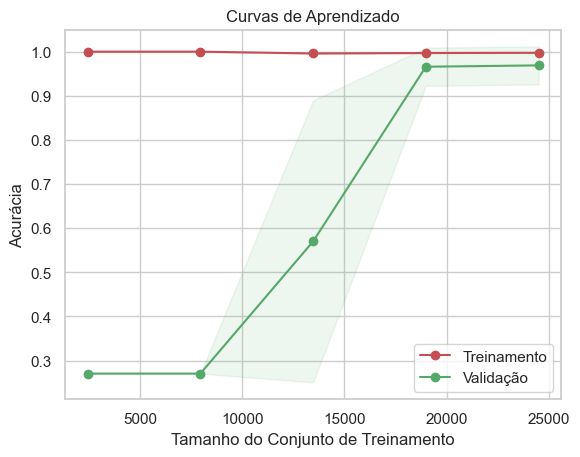

In [37]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X_vectorizer_reduced, y, cv=5, scoring='f1_macro')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Acurácia')
plt.title('Curvas de Aprendizado')
plt.savefig('ca_t3.png', dpi=300, bbox_inches='tight')
plt.legend(loc='best')
plt.show()

### 4º Treinamento do Random Forest (Usando Class_Weight e Features Selection do treinamento 2)

In [25]:
importances = model_rf.feature_importances_
print(f"{len(importances)}\n")
#print(sorted(importances,reverse=True))

threshold = 2e-5

important_features = [feature for feature, importance in zip(vectorizer.get_feature_names_out() , importances) if importance >= threshold]
#print(type(X_train))
print(f"Variáveis importantes: {len(important_features)}\n")
#print(f"Variáveis importantes: {important_features}")

feature_names = vectorizer.get_feature_names_out()
important_indices = [list(feature_names).index(feature) for feature in important_features]

X_train_reduced = X_train[:, important_indices]
#X_train_reduced = X_train[important_features]
X_test_reduced = X_test[:, important_indices]

print(X_train_reduced.shape[1])

24660

Variáveis importantes: 1876

1876


In [38]:
model_rf = RandomForestClassifier(n_estimators = 50, random_state = seed, class_weight="balanced").fit(X_train_reduced, y_train)
print(model_rf.score(X_test_reduced, y_test), '\n')
y_pred = model_rf.predict(X_test_reduced)
print(classification_report(y_test, y_pred))

0.9957530218882719 

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3914
           1       1.00      0.99      0.99      2208

    accuracy                           1.00      6122
   macro avg       1.00      0.99      1.00      6122
weighted avg       1.00      1.00      1.00      6122



[[3911    3]
 [  23 2185]]


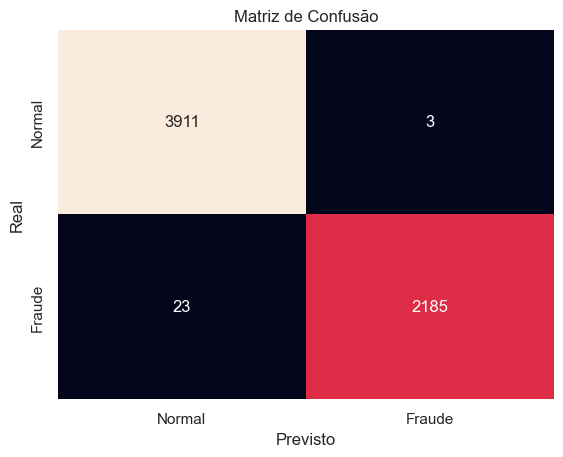

In [58]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.savefig('cm_t4.png', dpi=300, bbox_inches='tight')
plt.show()

In [59]:
depths = [tree.tree_.max_depth for tree in model_rf.estimators_]
soma = 0
menor = float('inf')
maior = float('-inf')
cnt = 0

for i, depth in enumerate(depths):
    #print(f"Árvore {i}: Profundidade = {depth}")
    soma += depth
    cnt += 1
    if(depth < menor):
        menor = depth
    if(depth > maior):
        maior = depth

print(f"MENOR PROFUNDIDADE: {menor}")
print(f"MAIOR PROFUNDIDADE: {maior}")
print(f"\nMÉDIA DAS PROFUNDIDADES: {round(soma/cnt)}")

MENOR PROFUNDIDADE: 160
MAIOR PROFUNDIDADE: 309

MÉDIA DAS PROFUNDIDADES: 219


In [60]:
scores = cross_val_score(model_rf, X_train_reduced, y_train, cv=5, scoring="accuracy")
print(f"Validação Cruzada Scores: {scores}")
print(f"Média da Validação Cruzada: {scores.mean()}")

Validação Cruzada Scores: [0.99387505 0.99469063 0.99448642 0.99591587 0.99550745]
Média da Validação Cruzada: 0.9948950837226448


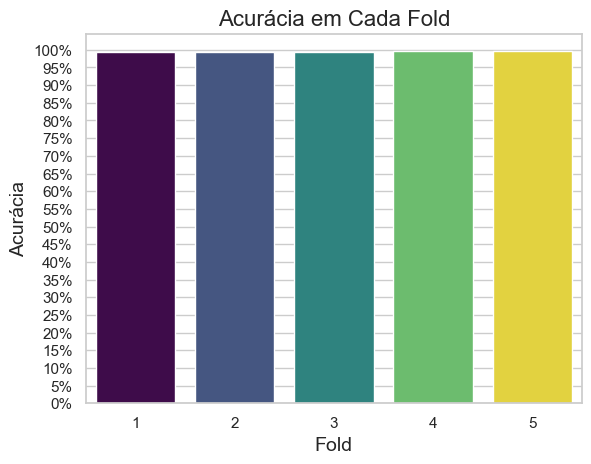

In [61]:
df = pd.DataFrame({'Fold': range(1, 6), 'Accuracy': scores})

sns.set_theme(style="whitegrid")
bar_plot = sns.barplot(x='Fold', y='Accuracy', data=df, hue='Fold', palette='viridis', errorbar=None, legend=False)
plt.gca().set_yticks([i / 100 for i in range(100, -1, -5)])
plt.gca().set_yticklabels([f'{i}%' for i in range(100, -1, -5)])
plt.title('Acurácia em Cada Fold', fontsize=16)
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Acurácia', fontsize=14)
plt.savefig('vc_t4.png', dpi=300, bbox_inches='tight')
plt.show()

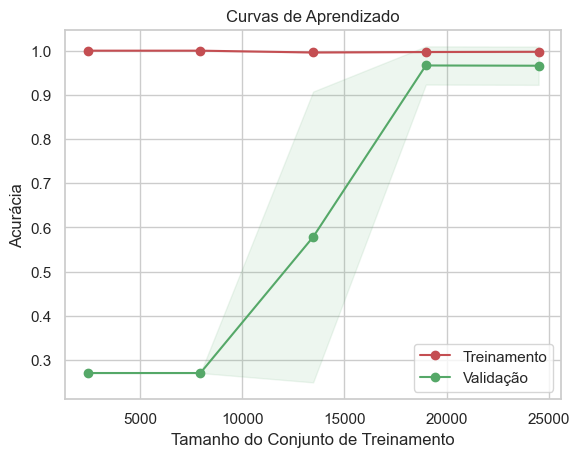

In [39]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X_vectorizer_reduced, y, cv=5, scoring='f1_macro')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Acurácia')
plt.title('Curvas de Aprendizado')
plt.savefig('ca_t4.png', dpi=300, bbox_inches='tight')
plt.legend(loc='best')
plt.show()

### 5º Treinamento do Random Forest (Usando Class_Weight e Features Selection do treinamento 2 com max_depth e trees)

In [169]:
importances = model_rf.feature_importances_
print(f"{len(importances)}\n")
#print(sorted(importances,reverse=True))

threshold = 2e-5

important_features = [feature for feature, importance in zip(vectorizer.get_feature_names_out() , importances) if importance >= threshold]
#print(type(X_train))
print(f"Variáveis importantes: {len(important_features)}\n")
#print(f"Variáveis importantes: {important_features}")

feature_names = vectorizer.get_feature_names_out()
important_indices = [list(feature_names).index(feature) for feature in important_features]
X_vectorizer_reduced = X_vectorizer[:, important_indices]

X_train_reduced = X_train[:, important_indices]
#X_train_reduced = X_train[important_features]
X_test_reduced = X_test[:, important_indices]

print(X_train_reduced.shape[1])

24660

Variáveis importantes: 1876

1876


In [132]:
trees = 25
seed = 7
depth = 150

In [163]:
model_rf = RandomForestClassifier(n_estimators = trees, random_state = seed, max_depth = depth,class_weight={0:0.1, 1:3.5}).fit(X_train_reduced, y_train)
print(model_rf.score(X_test_reduced, y_test), '\n')
y_pred = model_rf.predict(X_test_reduced)
print(classification_report(y_test, y_pred))

0.9957530218882719 

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3914
           1       1.00      0.99      0.99      2208

    accuracy                           1.00      6122
   macro avg       1.00      0.99      1.00      6122
weighted avg       1.00      1.00      1.00      6122



In [183]:
model_rf = RandomForestClassifier(n_estimators = trees, random_state = seed, max_depth = depth,class_weight="balanced").fit(X_train, y_train)
print(model_rf.score(X_test, y_test), '\n')
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred))

0.9728846782097353 

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3914
           1       1.00      0.93      0.96      2208

    accuracy                           0.97      6122
   macro avg       0.98      0.96      0.97      6122
weighted avg       0.97      0.97      0.97      6122



[[3912    2]
 [  24 2184]]


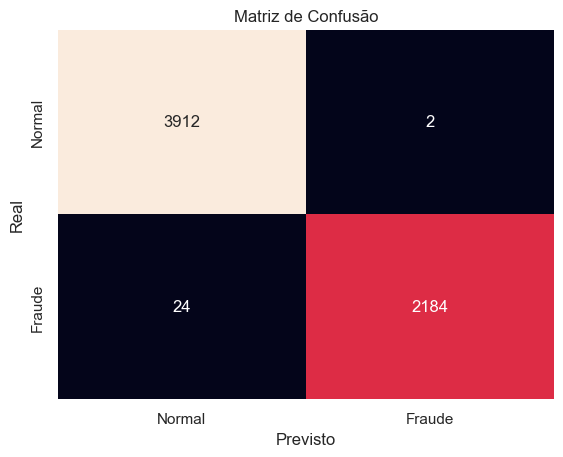

In [164]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.savefig('cm_t5.png', dpi=300, bbox_inches='tight')
plt.show()

In [108]:
depths = [tree.tree_.max_depth for tree in model_rf.estimators_]
soma = 0
menor = float('inf')
maior = float('-inf')
cnt = 0

for i, depth in enumerate(depths):
    #print(f"Árvore {i}: Profundidade = {depth}")
    soma += depth
    cnt += 1
    if(depth < menor):
        menor = depth
    if(depth > maior):
        maior = depth

print(f"MENOR PROFUNDIDADE: {menor}")
print(f"MAIOR PROFUNDIDADE: {maior}")
print(f"\nMÉDIA DAS PROFUNDIDADES: {round(soma/cnt)}")

MENOR PROFUNDIDADE: 140
MAIOR PROFUNDIDADE: 140

MÉDIA DAS PROFUNDIDADES: 140


In [134]:
scores = cross_val_score(model_rf, X_train, y_train, cv=5, scoring="accuracy")
print(f"Validação Cruzada Scores: {scores}")
print(f"Média da Validação Cruzada: {scores.mean()}")

Validação Cruzada Scores: [0.99285423 0.9938738  0.99203594 0.99550745 0.9938738 ]
Média da Validação Cruzada: 0.9936290441402402


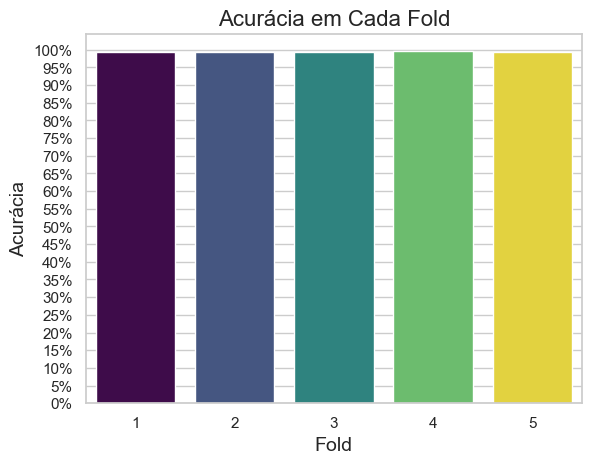

In [104]:
df = pd.DataFrame({'Fold': range(1, 6), 'Accuracy': scores})

sns.set_theme(style="whitegrid")
bar_plot = sns.barplot(x='Fold', y='Accuracy', data=df, hue='Fold', palette='viridis', errorbar=None, legend=False)
plt.gca().set_yticks([i / 100 for i in range(100, -1, -5)])
plt.gca().set_yticklabels([f'{i}%' for i in range(100, -1, -5)])
plt.title('Acurácia em Cada Fold', fontsize=16)
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Acurácia', fontsize=14)
plt.savefig('vc_t5.png', dpi=300, bbox_inches='tight')
plt.show()

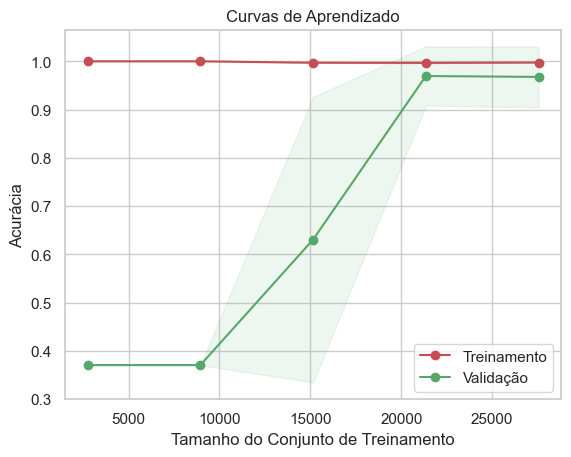

In [170]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X_vectorizer_reduced, y, cv=5, scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Acurácia')
plt.title('Curvas de Aprendizado')
plt.savefig('ca_t5.png', dpi=300, bbox_inches='tight')
plt.legend(loc='best')
plt.show()

### 6º Treinamento do Random Forest (Usando Class_Weight e Features Selection do treinamento 5)

In [184]:
importances = model_rf.feature_importances_
print(f"{len(importances)}\n")
#print(sorted(importances,reverse=True))

threshold = 2e-4

important_features = [feature for feature, importance in zip(vectorizer.get_feature_names_out() , importances) if importance >= threshold]
#print(type(X_train))
print(f"Variáveis importantes: {len(important_features)}\n")
#print(f"Variáveis importantes: {important_features}")

feature_names = vectorizer.get_feature_names_out()
important_indices = [list(feature_names).index(feature) for feature in important_features]

X_train_reduced = X_train[:, important_indices]
#X_train_reduced = X_train[important_features]
X_test_reduced = X_test[:, important_indices]

print(X_train_reduced.shape[1])

24660

Variáveis importantes: 277

277


In [200]:
trees = 25 #25 #10
seed = 7
depth = 110 #110 #90

In [211]:
model_rf = RandomForestClassifier(n_estimators = trees, random_state = seed, max_depth = depth, class_weight="balanced").fit(X_train_reduced, y_train)
print(model_rf.score(X_test_reduced, y_test), '\n')
y_pred = model_rf.predict(X_test_reduced)
print(classification_report(y_test, y_pred))

0.9933028422084286 

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3914
           1       1.00      0.99      0.99      2208

    accuracy                           0.99      6122
   macro avg       0.99      0.99      0.99      6122
weighted avg       0.99      0.99      0.99      6122



[[3910    4]
 [  26 2182]]


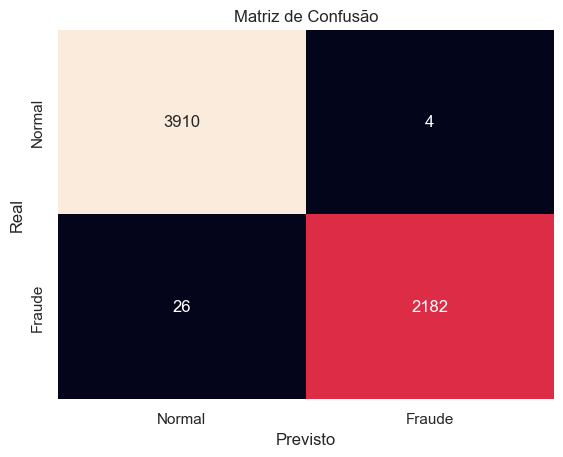

In [206]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g', cbar=False, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.savefig('cm_t6.png', dpi=300, bbox_inches='tight')
plt.show()

In [188]:
depths = [tree.tree_.max_depth for tree in model_rf.estimators_]
soma = 0
menor = float('inf')
maior = float('-inf')
cnt = 0

for i, depth in enumerate(depths):
    #print(f"Árvore {i}: Profundidade = {depth}")
    soma += depth
    cnt += 1
    if(depth < menor):
        menor = depth
    if(depth > maior):
        maior = depth

print(f"MENOR PROFUNDIDADE: {menor}")
print(f"MAIOR PROFUNDIDADE: {maior}")
print(f"\nMÉDIA DAS PROFUNDIDADES: {round(soma/cnt)}")

MENOR PROFUNDIDADE: 71
MAIOR PROFUNDIDADE: 95

MÉDIA DAS PROFUNDIDADES: 86


In [189]:
scores = cross_val_score(model_rf, X_train, y_train, cv=5, scoring="accuracy")
print(f"Validação Cruzada Scores: {scores}")
print(f"Média da Validação Cruzada: {scores.mean()}")

Validação Cruzada Scores: [0.9924459  0.99264856 0.97365734 0.99489483 0.98060037]
Média da Validação Cruzada: 0.9868493998000293


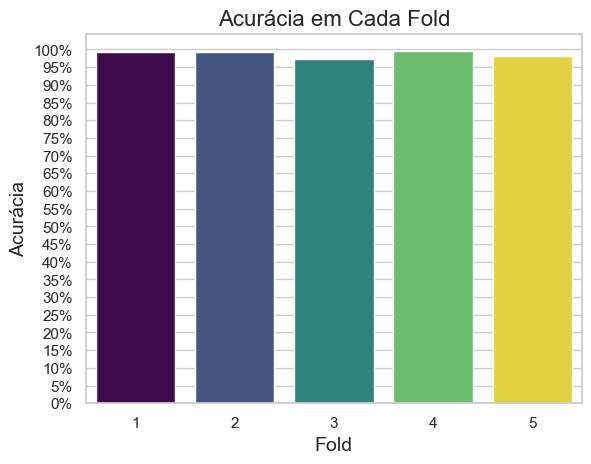

In [776]:
df = pd.DataFrame({'Fold': range(1, 6), 'Accuracy': scores})

sns.set_theme(style="whitegrid")
bar_plot = sns.barplot(x='Fold', y='Accuracy', data=df, hue='Fold', palette='viridis', errorbar=None, legend=False)
plt.gca().set_yticks([i / 100 for i in range(100, -1, -5)])
plt.gca().set_yticklabels([f'{i}%' for i in range(100, -1, -5)])
plt.title('Acurácia em Cada Fold', fontsize=16)
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Acurácia', fontsize=14)
plt.savefig('vc_t6.png', dpi=300, bbox_inches='tight')
plt.show()

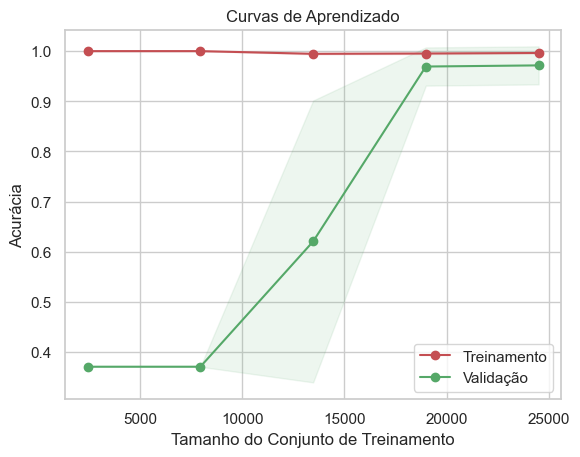

In [196]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X_vectorizer_reduced, y, cv=5, scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Acurácia')
plt.title('Curvas de Aprendizado')
plt.savefig('ca_t6.png', dpi=300, bbox_inches='tight')
plt.legend(loc='best')
plt.show()

### Exportando Modelo

In [778]:
jb.dump(model_rf, 'modelo_sql_injection_reduced.pkl')
jb.dump(vectorizer, 'vectorizer_tfidf.pkl')
jb.dump(important_indices, 'important_indices.pkl')

['important_indices.pkl']

# Embeddings (Word2Vec)

In [189]:
sentences = [row.split() for row in df['Sentence']]

In [190]:
start_time = tm.time()
model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, seed = 7)
end_time = tm.time()
print(f"Tempo de Vetorização: {end_time - start_time}")

Tempo de Vetorização: 1.050252914428711


In [191]:
def get_average_vector(text):
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

In [192]:
X = np.array([get_average_vector(text) for text in df['Sentence']])
y = df['Label'].values

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, shuffle=True)

#jb.dump(X_train, 'X_train.pkl')
#jb.dump(X_test, 'X_test.pkl')
#jb.dump(y_train, 'y_train.pkl')
#jb.dump(y_test, 'y_test.pkl')

In [1606]:
start_time = tm.time()
#model_rf = RandomForestClassifier(n_estimators=50, max_depth= 50, random_state=9, class_weight="balanced").fit(X_train, y_train) 7  e 12
#8 14
#9 14
#9 15
model_rf = RandomForestClassifier(n_estimators=8, max_depth= 15, random_state=7, class_weight="balanced").fit(X_train, y_train)
end_time = tm.time()
print(f"Tempo de Treinamento: {end_time - start_time}")

Tempo de Treinamento: 1.6357676982879639


In [1607]:
y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9957    0.9972    0.9964      3914
           1     0.9950    0.9923    0.9937      2208

    accuracy                         0.9954      6122
   macro avg     0.9953    0.9947    0.9950      6122
weighted avg     0.9954    0.9954    0.9954      6122



In [1608]:
class_names = ["Normal", "Fraude"]

[[3903   11]
 [  17 2191]]
True Negatives (Classe 0 correta): 3903
False Positives (Classe 0 → 1): 11
False Negatives (Classe 1 → 0): 17
True Positives (Classe 1 correta): 2191


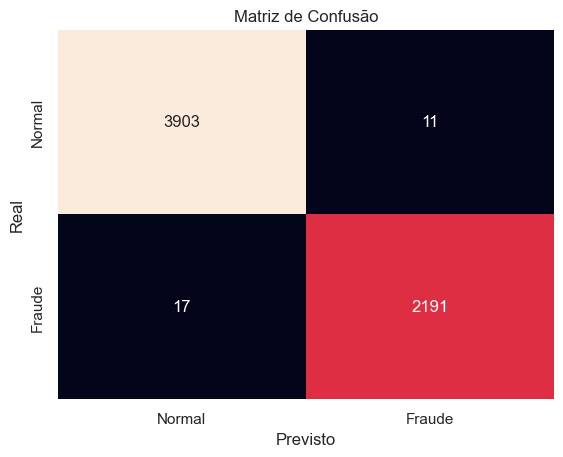

In [1609]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Classe 0 correta): {tn}")
print(f"False Positives (Classe 0 → 1): {fp}")
print(f"False Negatives (Classe 1 → 0): {fn}")
print(f"True Positives (Classe 1 correta): {tp}")
sns.heatmap(cm, annot=True, fmt='g', cbar=False, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
#plt.savefig('cm_t7.png', dpi=300, bbox_inches='tight')
plt.show()

In [1591]:
depths = [tree.tree_.max_depth for tree in model_rf.estimators_]
soma = 0
menor = float('inf')
maior = float('-inf')
cnt = 0

for i, depth in enumerate(depths):
    #print(f"Árvore {i}: Profundidade = {depth}")
    soma += depth
    cnt += 1
    if(depth < menor):
        menor = depth
    if(depth > maior):
        maior = depth

print(f"MENOR PROFUNDIDADE: {menor}")
print(f"MAIOR PROFUNDIDADE: {maior}")
print(f"\nMÉDIA DAS PROFUNDIDADES: {round(soma/cnt)}")

MENOR PROFUNDIDADE: 15
MAIOR PROFUNDIDADE: 15

MÉDIA DAS PROFUNDIDADES: 15


In [1592]:
scores = cross_val_score(model_rf, X_train, y_train, cv=5, scoring="accuracy")
print(f"Validação Cruzada Scores: {scores}")
print(f"Média da Validação Cruzada: {scores.mean()}")

Validação Cruzada Scores: [0.99489588 0.99550745 0.99428221 0.99612007 0.99612007]
Média da Validação Cruzada: 0.9953851380079286


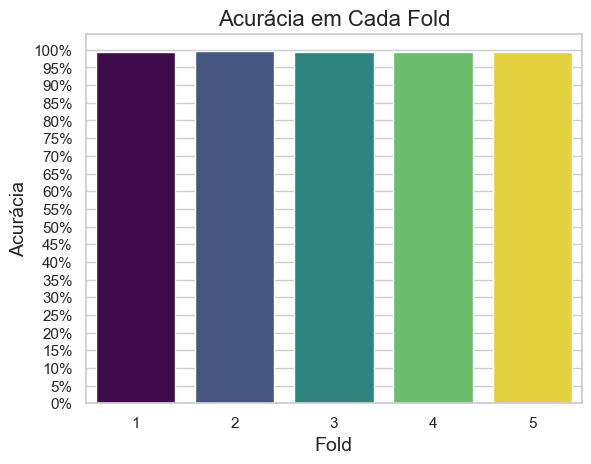

In [1498]:
df = pd.DataFrame({'Fold': range(1, 6), 'Accuracy': scores})

sns.set_theme(style="whitegrid")
bar_plot = sns.barplot(x='Fold', y='Accuracy', data=df, hue='Fold', palette='viridis', errorbar=None, legend=False)
plt.gca().set_yticks([i / 100 for i in range(100, -1, -5)])
plt.gca().set_yticklabels([f'{i}%' for i in range(100, -1, -5)])
plt.title('Acurácia em Cada Fold', fontsize=16)
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Acurácia', fontsize=14)
#plt.savefig('vc_t7.png', dpi=300, bbox_inches='tight')
plt.show()

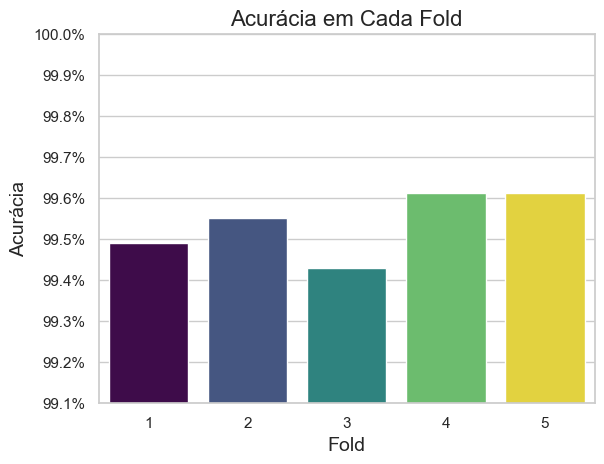

In [1603]:
df = pd.DataFrame({'Fold': range(1, 6), 'Accuracy': scores})

sns.set_theme(style="whitegrid")
bar_plot = sns.barplot(x='Fold', y='Accuracy', data=df, hue='Fold', palette='viridis', errorbar=None, legend=False)

# Ajustando os ticks do eixo y
plt.gca().set_yticks([i / 1000 for i in range(991, 1001)])  # De 99.1 a 100.0
plt.gca().set_yticklabels([f'{i / 10:.1f}%' for i in range(991, 1001)])  # Labels de 99.1% a 100.0%

# Definindo os limites do eixo y
plt.ylim(0.991, 1.000)  # Limite entre 99.1% e 100.0%

plt.title('Acurácia em Cada Fold', fontsize=16)
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Acurácia', fontsize=14)
#plt.savefig('vc_zoom_t7.png', dpi=300, bbox_inches='tight')
plt.show()

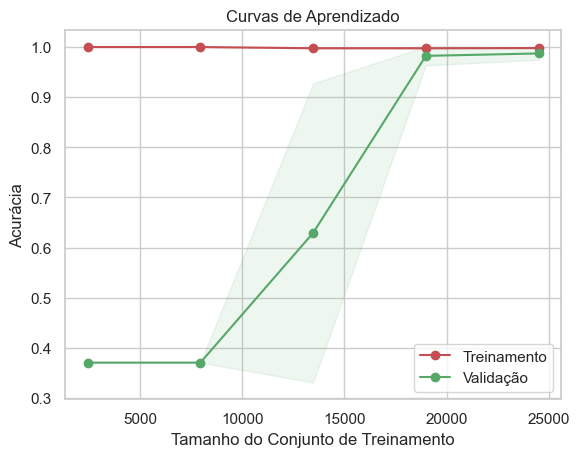

In [1593]:
train_sizes, train_scores, test_scores = learning_curve(model_rf, X, y, cv=5, scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='r', label='Treinamento')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validação')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.xlabel('Tamanho do Conjunto de Treinamento')
plt.ylabel('Acurácia')
plt.title('Curvas de Aprendizado')
plt.legend(loc='best')
#plt.savefig('ca_t7.png', dpi=300, bbox_inches='tight')
plt.show()

In [1602]:
jb.dump(model, 'model_word2vec.pkl')
jb.dump(model_rf, 'model_rf_word2vec.pkl')

['model_rf_word2vec.pkl']

# Métricas TF_IDF x Word2Vec -> Tempo de Vetorização e Tempo de Treinamento

#### TF_IDF

Tempo de Vetorização: 0.27167177200317383 segundos\
Tempo de Treinamento: 0.22006750106811523 segundos

#### Word2Vec

Tempo de Vetorização: 1.3120837211608887 segundos\
Tempo de Treinamento: 1.5795087814331055 segundos

# Métricas TF_IDF x Word2Vec -> Tempo de Execução, Ram, CPU (Sem Paralelismo)

## TF-IDF

SQL Nomal: 19390\
SQL Injection: 11218\
Total: 30608\
Tempo de execução: 40.2596 segundos\
Uso de memória inicial: 152.64 MB\
Uso de memória final: 154.42 MB\
Uso de CPU inicial: 0.0%\
Uso de CPU final: 99.4%

## Word2Vec

SQL Nomal: 19349\
SQL Injection: 11259\
Total: 30608\
Tempo de execução: 17.8674 segundos\
Uso de memória inicial: 193.36 MB\
Uso de memória final: 194.01 MB\
Uso de CPU inicial: 0.0%\
Uso de CPU final: 99.9%

# Métricas TF_IDF x Word2Vec -> Tempo de Execução, Ram, CPU (Com Paralelismo)

## TF-IDF

SQL Normal: 19390\
SQL Injection: 11218\
Total: 30608\
Tempo de execução: 11.7496 segundos\
Uso de memória inicial: 155.07 MB\
Uso de memória final: 156.77 MB\
Uso de CPU inicial por núcleo: [5.1, 3.0, 1.0, 1.0]\
Uso de CPU final por núcleo: [93.3, 99.8, 91.2, 92.3]\
Uso total de CPU inicial: 10.1%\
Uso total de CPU final: 94.15%

## Word2Vec

SQL Normal: 19349\
SQL Injection: 11259\
Total: 30608\
Tempo de execução: 4.9109 segundos\
Uso de memória inicial: 193.81 MB\
Uso de memória final: 196.16 MB\
Uso de CPU inicial por núcleo: [1.0, 3.1, 1.0, 5.0]\
Uso de CPU final por núcleo: [94.5, 99.4, 91.9, 90.6]\
Uso total de CPU inicial: 10.1%\
Uso total de CPU final: 94.1%

# Próximos Passos

1. Outliers
2. Parar a divisão se não melhorar a divisão (gini impureza)
3. Analisar Variância
4. Verificar se existe alguma forma de analisar a correlação com o alvo
5. Em relação aos Testes, verificar o polars ao invés do pandas para deixar mais real os testes (Velocidade)
6. Analisar linguagem de programação de baixo adequada para usar em web (Talvez Rust e WebAssembly)

# Extras / Anotações de Códigos

### Matriz dos TF-IDF e em forma de array

In [161]:
#MATRIZ TF-IDF

#vectorizer = TfidfVectorizer(use_idf=True)
#X_vectorizer = vectorizer.fit_transform(X)
#print(X_vectorizer.toarray())
#feature_names = vectorizer.get_feature_names_out()
#df = pd.DataFrame(X_vectorizer.todense(), columns=feature_names)
#display(df)

In [162]:
#ARRAY TF-IDF

#print(X_vectorizer.todense())
#print(type(X_vectorizer.todense()))
#X_dense = np.asarray(X_vectorizer.todense())
#print(type(X_dense))